In [4]:
#Importar librerias
import PIL.Image as img

# Desafio bitwise operators

In [ ]:
from win32comext import bits


class Imagen:
    def __init__(self, nombre_archivo):
        '''Inicializar la clase Imagen, cargando una imagen desde la carpeta del proyecto y guardando su width height y pixeles'''
        self.image = img.open(nombre_archivo)
        self.pixels = self.image.load()
        self.width, self.height = self.image.size
        return
    
    def encode(self, msg, partes):
        '''
        Funcion que codifica un mensaje dentro de una imagen, retornando una copia modificada de la original.
        La idea es copiar el mensaje a toda la foto. 
        Parametros:

        self: imagen

        msg: mensaje a codificar

        partes: partes a dividir el mensaje codificado. "Cada cuantos bits guardamos una letra?"
        Valores aceptados serian 3, 6 y 8.
        3 partes = guardar cada letra en 1 color
        6 partes = guardar cada letra en 2 colores
        8 partes = guardar cada letra en 3 colores
        
        '''
        newimg = self.image.copy()

        # Add a null character '\x00' as a delimiter so the decoder knows where to stop
        msg += chr(0)
        
        # Convert the message into a list of 1s and 0s
        bits = ''.join([format(ord(char), '08b') for char in msg])
        
        bit_index = 0
        num_bits = len(bits)
        for x in range(self.width):
            for y in range(self.height): # ahora si empezamos a iterar sobre la imagen
                if bit_index >= num_bits:
                    break # si mensaje ya a sido codificado romper bucle
                r, g, b = newimg.getpixel((x, y)) # la idea es quitar el bit menos significativo de cada color de cada pixel
                if partes >= 3:
                    r >>= 1
                    r <<= 1
                    bit_index += 1
                    if partes >= 6:  # dejarlo igual si el ultimo bit es 0, o restarle 1 si es 1
                        g >>= 1
                        g <<= 1
                        bit_index += 1                        
                        if partes == 8:
                            b >>= 1
                            b <<= 1
                        bit_index += 1
                newimg.putpixel((x, y), (r, g, b))
        
                    
        return newimg # la copia modificada
    
    def decode(self):
        return # msg_encondido
    
    def __ne__(self, other):
        return True or False
    
    # def recortar(self, (2,2), (10,10)):
        return # algo
        
        
i1 = Imagen("tuxy.jpg")
# i2 = i1.encode("profe quiero un 7", 8)
# print(i2.decode())

# tests
# assert i1 != i2


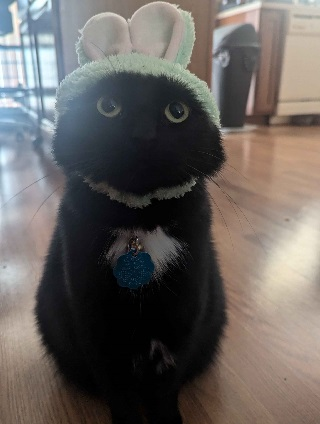

In [16]:
display(i1.image)


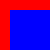

In [22]:
import PIL.Image as img

imagen = img.new("RGB", (100, 100), (255,0,0))
for i in range(10,90):
    for j in range(10, 50):
        imagen.putpixel((i,j), (0,0,255))

nueva = img.new("RGB", (imagen.size[0]//2, imagen.size[1]//2))
for i in range(imagen.size[0]//2):
    for j in range(imagen.size[1]//2):
        r,g,b = imagen.getpixel((i,j))
        nueva.putpixel((i,j), (r,g,b))
nueva

In [13]:
class Complejo:
    def __init__(self, real, imag):
        self.r = real
        self.i = imag
        
    def __str__(self):
        return "(" + str(self.r) + "," + str(self.i) + ")"
    
    def __add__(self, other):
        return Complejo(self.r+other.r, self.i+other.i)
    
    def __ne__(self, other):
        return self.r != other.r or self.i != other.i
        
c1 = Complejo(3,2)
c2 = c1+c1
print(c1, c2)

(3,2) (6,4)


In [14]:
c1 != c2

True

In [15]:
c1 != c1

False